# Bài tập thực hành tuần 6
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap



In [140]:
blobs = pd.read_csv(r'D:\Data-Mining_MTH10358\Homeworks\TH\6\data.csv')
colnames = list(blobs.columns[1:-1])
print(blobs.head())

   ID       x       y  cluster
0   1  35.190  12.189        1
1   2  26.288  41.718        2
2   3   0.376  15.506        0
3   4  26.116   3.963        1
4   5  25.893  31.515        2


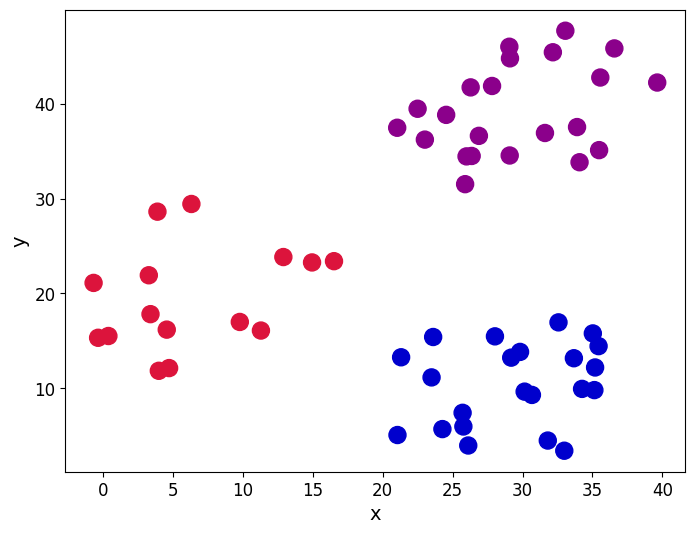

In [141]:
customcmap = ListedColormap(["crimson", "mediumblue", "darkmagenta"])

fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=blobs['x'], y=blobs['y'], s=150,
            c=blobs['cluster'].astype('category'),
            cmap = customcmap)
ax.set_xlabel(r'x', fontsize=14)
ax.set_ylabel(r'y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [142]:
def initiate_centroids(k, dset):
    '''
    Select k data points as centroids
    k: number of centroids
    dset: pandas dataframe
    '''
    centroids = dset.sample(k)
    return centroids

np.random.seed(42)
k=3
df = blobs[['x','y']]
centroids = initiate_centroids(k, df)
print(centroids)

         x       y
0   35.190  12.189
5   23.606  15.402
34  23.492  11.142


In [143]:
def rsserr(a,b):
    '''
    Calculate the root of sum of squared errors.
    a and b are numpy arrays
    '''
    return np.sum(np.square(a-b))

for i, centroid in enumerate(range(centroids.shape[0])):
    err = rsserr(centroids.iloc[centroid,:], df.iloc[34,:])
    print('Error for centroid {0}: {1:.2f}'.format(i, err))

Error for centroid 0: 137.94
Error for centroid 1: 18.16
Error for centroid 2: 0.00


In [144]:
def centroid_assignation(dset, centroids):
    '''
    Given a dataframe `dset` and a set of `centroids`, we assign each
    data point in `dset` to a centroid.
    - dset - pandas dataframe with observations
    - centroids - pa das dataframe with centroids
    '''
    k = centroids.shape[0]
    n = dset.shape[0]
    assignation = []
    assign_errors = []

    for obs in range(n):
        # Estimate error
        all_errors = np.array([])
        for centroid in range(k):
            err = rsserr(centroids.iloc[centroid, :], dset.iloc[obs,:])
            all_errors = np.append(all_errors, err)

        # Get the nearest centroid and the error
        nearest_centroid =  np.where(all_errors==np.amin(all_errors))[0].tolist()[0]
        nearest_centroid_error = np.amin(all_errors)

        # Add values to corresponding lists
        assignation.append(nearest_centroid)
        assign_errors.append(nearest_centroid_error)

    return assignation, assign_errors

In [145]:
df.loc[:,'centroid'], df.loc[:,'error'] = centroid_assignation(df, centroids)
print(df.head())

        x       y  centroid       error
0  35.190  12.189         0    0.000000
1  26.288  41.718         1  699.724980
2   0.376  15.506         1  539.643716
3  26.116   3.963         2   58.423417
4  25.893  31.515         1  264.859138


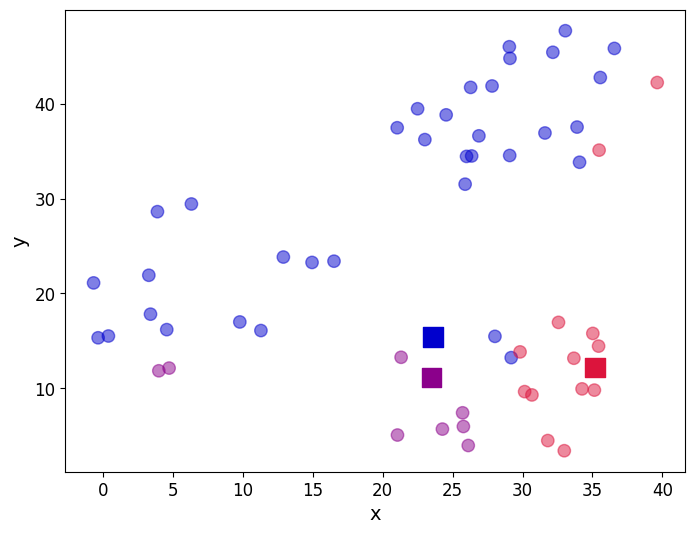

In [146]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:,0], df.iloc[:,1],  marker = 'o',
            c=df['centroid'].astype('category'),
            cmap = customcmap, s=80, alpha=0.5)
plt.scatter(centroids.iloc[:,0], centroids.iloc[:,1],
            marker = 's', s=200, c=[0, 1, 2],
            cmap = customcmap)
ax.set_xlabel(r'x', fontsize=14)
ax.set_ylabel(r'y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [147]:
print("total error: {0:.2f}".format(df['error'].sum()))

total error: 20408.22


In [148]:
centroids = df.groupby('centroid').agg('mean').loc[:,colnames].reset_index(drop=True)
print(centroids)

           x          y
0  33.703214  15.017429
1  20.595944  30.595361
2  19.602778   8.496556


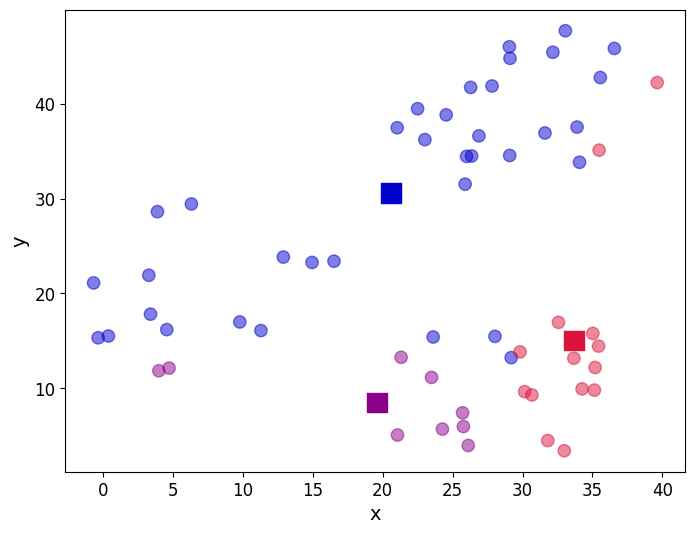

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:,0], df.iloc[:,1],  marker = 'o',
            c=df['centroid'].astype('category'),
            cmap = customcmap, s=80, alpha=0.5)
plt.scatter(centroids.iloc[:,0], centroids.iloc[:,1],
            marker = 's', s=200,
            c=[0, 1, 2], cmap = customcmap)
ax.set_xlabel(r'x', fontsize=14)
ax.set_ylabel(r'y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [151]:
def kmeans(dset, k=2, tol=1e-4):
    '''
    K-means implementationd for a
    `dset`: DataFrame with observations
    `k`: number of clusters, default k=2
    `tol`: tolerance=1E-4
    '''
    # Let us work in a copy, so we don't mess the original
    working_dset = dset.copy()
    # We define some variables to hold the error, the
    # stopping signal and a counter for the iterations
    err = []
    goahead = True
    j = 0

    # Step 2: Initiate clusters by defining centroids
    centroids = initiate_centroids(k, dset)

    while(goahead):
        # Step 3 and 4 - Assign centroids and calculate error
        working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
        err.append(sum(j_err))

        # Step 5 - Update centroid position
        centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)

        # Step 6 - Restart the iteration
        if j>0:
            # Is the error less than a tolerance (1E-4)
            if err[j-1]-err[j]<=tol:
                goahead = False
        j+=1

    working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
    centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)
    return working_dset['centroid'], j_err, centroids

In [152]:
np.random.seed(42)
df['centroid'], df['error'], centroids = kmeans(df.iloc[:,:-2], k=3, tol=1e-4)
print(df.head())

        x       y  centroid      error
0  35.190  12.189         0  37.415091
1  26.288  41.718         1  16.201232
2   0.376  15.506         2  51.798518
3  26.116   3.963         0  52.188602
4  25.893  31.515         1  74.265774


In [153]:
print(centroids)

           x          y
0  29.330864  10.432409
1  29.527364  39.328909
2   6.322867  19.559800


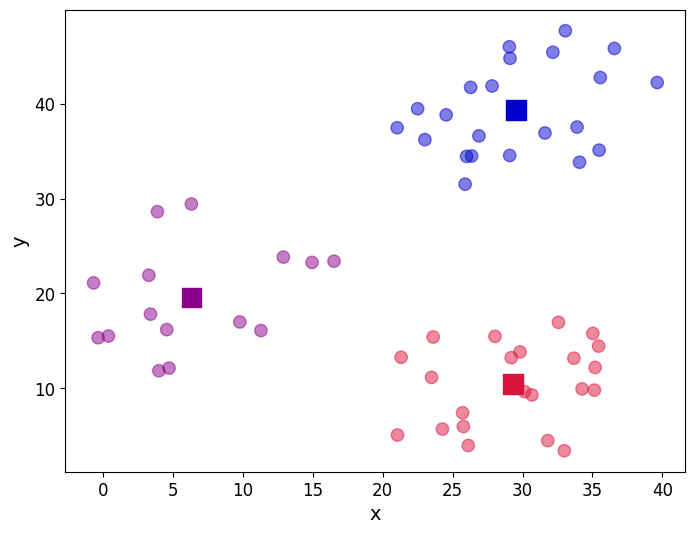

In [154]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:,0], df.iloc[:,1],  marker = 'o',
            c=df['centroid'].astype('category'),
            cmap = customcmap, s=80, alpha=0.5)
plt.scatter(centroids.iloc[:,0], centroids.iloc[:,1],
            marker = 's', s=200, c=[0, 1, 2],
            cmap = customcmap)
ax.set_xlabel(r'x', fontsize=14)
ax.set_ylabel(r'y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

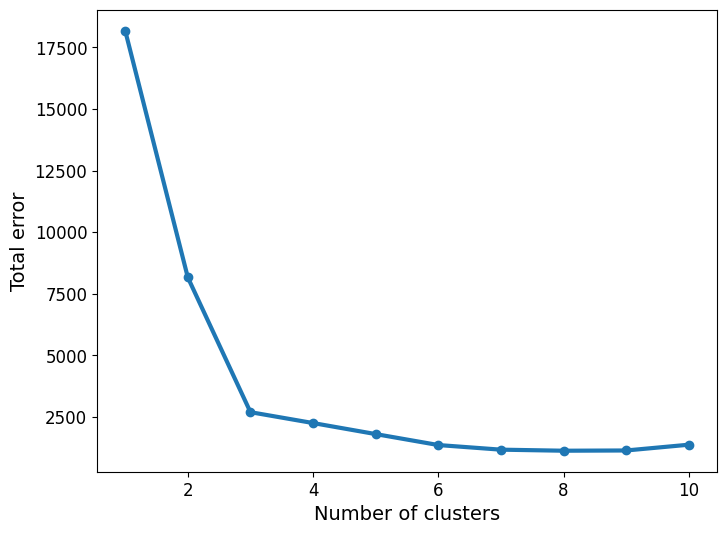

In [155]:
err_total = []
n = 10

df_elbow = blobs[['x','y']]

for i in range(n):
    _, my_errs, _ = kmeans(df_elbow, i+1)
    err_total.append(sum(my_errs))
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(1,n+1), err_total, linewidth=3, marker='o')
ax.set_xlabel(r'Number of clusters', fontsize=14)
ax.set_ylabel(r'Total error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()